# Salary Analysis EDA

Notebook này đọc và khám phá file `data/analysis/salary_analysis_clean.csv`.

Mục tiêu: hiểu dataset salary numeric đã lọc sạch, đồng thời học các pandas method hay dùng cho phân tích dữ liệu lương.

In [1]:
from pathlib import Path
import ast
import re
import unicodedata

import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

try:
    from IPython.display import display
except Exception:  # pragma: no cover - notebook convenience fallback
    def display(obj):
        if isinstance(obj, pd.DataFrame):
            print(obj.to_string(index=False))
        else:
            print(obj)


def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "analysis" / "salary_analysis_clean.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing data/analysis/salary_analysis_clean.csv")


REPO_ROOT = find_repo_root()
SALARY_PATH = REPO_ROOT / "data" / "analysis" / "salary_analysis_clean.csv"

print(f"Repo root: {REPO_ROOT}")
print(f"Salary analysis file: {SALARY_PATH}")

Repo root: G:\project\Vietnam IT Job Market Intelligence
Salary analysis file: G:\project\Vietnam IT Job Market Intelligence\data\analysis\salary_analysis_clean.csv


## 1. Load dữ liệu

Pandas cần học: `pd.read_csv`, `.shape`, `.columns`, `.head()`.

`encoding="utf-8-sig"` giúp đọc CSV có BOM tốt hơn, đặc biệt khi file từng được mở bằng Excel.

In [2]:
if not SALARY_PATH.exists():
    raise FileNotFoundError(SALARY_PATH)

salary = pd.read_csv(SALARY_PATH, encoding="utf-8-sig")

print(f"Rows: {len(salary):,}")
print(f"Columns: {len(salary.columns):,}")
display(pd.DataFrame({"column": salary.columns}))
display(salary.head(10))

Rows: 504
Columns: 40


,column
0,source
1,url
2,job_id
3,title
4,company
5,location
6,salary_raw
7,salary_min
8,salary_max
9,salary_currency


,source,url,job_id,title,company,location,salary_raw,salary_min,salary_max,salary_currency,skills,experience_raw,experience_min,experience_max,description,scraped_at,parse_status,posted_raw,posted_at,valid_through,location_cities,seniority,work_mode,employment_type,salary_period,_input_file,scraped_at_parsed,posted_at_parsed,valid_through_parsed,_has_numeric_salary,_salary_midpoint,_has_skills,_has_experience,_has_description,_quality_score,_scraped_at_sort,salary_midpoint,salary_suspicious_reason,_salary_raw_folded,salary_label
0,itviec,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec_10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,Hà Nội,1200 - 1600 USD,1200.0,1600.0,USD,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",Tối thiểu 04 năm,4.0,NaN,Top 3 Reasons To Join Us Môi trường trẻ trung Cơ hội phát triển rộng mở Thưởng lên tới 5 tháng lương/năm The Job - T...,2026-07-02T12:26:19.242549+00:00,ok,2026-06-12,2026-06-12,2026-07-17,"Ho Chi Minh, Ha Noi, Da Nang",middle,hybrid,full_time,month,itviec_salary_20260702_clean.csv,2026-07-02 12:26:19.242549+00:00,2026-06-12 00:00:00+00:00,2026-07-17 00:00:00+00:00,True,1400.0,True,True,True,116,2026-07-02 12:26:19.242549+00:00,1400.0,NaN,1200 - 1600 usd,numeric
1,itviec,https://itviec.com/it-jobs/10-nhan-su-danh-gia-ro-quet-lo-hong-antt-pentest-trung-tam-thong-tin-tin-dung-quoc-gia-vi...,itviec_10-nhan-su-danh-gia-ro-quet-lo-hong-antt-pentest-trung-tam-thong-tin-tin-dung-quoc-gia-viet-nam-cic-2734,[10] Nhân sự đánh giá rò quét lỗ hổng ANTT (Pentest),TRUNG TÂM THÔNG TIN TÍN DỤNG QUỐC GIA VIỆT NAM (CIC),Hà Nội,800 - 1500 USD,800.0,1500.0,USD,"Pentest, CompTIA Security+, Security",Tối thiểu 02 năm,2.0,NaN,"Top 3 Reasons To Join Us The Job 1.Dò quét, đánh giá lỗ hổng an ninh mạng: Định kỳ hoặc đột xuất thực hiện dò quét, ...",2026-07-02T13:04:37.825968+00:00,ok,2026-07-01,2026-07-01,2026-08-05,"Ho Chi Minh, Ha Noi, Da Nang",middle,onsite,full_time,month,itviec_salary_20260702_clean.csv,2026-07-02 13:04:37.825968+00:00,2026-07-01 00:00:00+00:00,2026-08-05 00:00:00+00:00,True,1150.0,True,True,True,116,2026-07-02 13:04:37.825968+00:00,1150.0,NaN,800 - 1500 usd,numeric
2,itviec,https://itviec.com/it-jobs/11-nhan-su-san-tim-moi-nguy-thread-huntting-trung-tam-thong-tin-tin-dung-quoc-gia-viet-na...,itviec_11-nhan-su-san-tim-moi-nguy-thread-huntting-trung-tam-thong-tin-tin-dung-quoc-gia-viet-nam-cic-2756,[11] Nhân sự săn tìm mối nguy (Thread huntting),TRUNG TÂM THÔNG TIN TÍN DỤNG QUỐC GIA VIỆT NAM (CIC),Hà Nội,800 - 1500 USD,800.0,1500.0,USD,"Pentest, CompTIA Security+, Security",Tối thiểu 02 năm,2.0,NaN,"Top 3 Reasons To Join Us The Job 1.Dò quét, đánh giá lỗ hổng an ninh mạng: Định kỳ hoặc đột xuất thực hiện dò quét, ...",2026-07-02T13:04:33.261306+00:00,ok,2026-07-01,2026-07-01,2026-08-05,"Ho Chi Minh, Ha Noi, Da Nang",middle,remote,full_time,month,itviec_salary_20260702_clean.csv,2026-07-02 13:04:33.261306+00:00,2026-07-01 00:00:00+00:00,2026-08-05 00:00:00+00:00,True,1150.0,True,True,True,116,2026-07-02 13:04:33.261306+00:00,1150.0,NaN,800 - 1500 usd,numeric
3,itviec,https://itviec.com/it-jobs/20-java-backend-devs-spring-boot-hibernate-oracle-thien-hoang-solutions-jsc-4542,itviec_20-java-backend-devs-spring-boot-hibernate-oracle-thien-hoang-solutions-jsc-4542,"20 Java Backend Devs (Spring Boot, Hibernate, Oracle)",Thien Hoang Solutions JSC,Hà Nội,1100 - 1900 USD,1100.0,1900.0,USD,"Java, Oracle, Hibernate, Spring Boot, MongoDB, MySQL, Python, Node.js, Go, AWS, Azure, Docker, Kubernetes, PostgreSQL",ít nhất 3 năm,3.0,NaN,Top 3 Reasons To Join Us Môi trường trẻ trung Cơ hội phát triển rộng mở Thưởng lên tới 5 tháng lương/năm The Job Phâ...,2026-07-02T12:23:33.916002+00:00,ok,2026-06-29,2026-06-29,2026-08-03,"Ho Chi Minh, Ha Noi, Da Nang",middle,hybrid,full_time,month,itviec_salary_

## 2. Chuẩn hóa kiểu dữ liệu cho EDA

File đầu vào đã là salary-clean dataset. Cell này không ghi đè file, chỉ tạo `salary_eda` để phân tích.

Pandas cần học: `.copy()`, `.astype("string")`, `.str.strip()`, `pd.to_numeric`, `pd.to_datetime(..., format="mixed")`.

In [3]:
salary_eda = salary.copy()

text_columns = [
    "source",
    "url",
    "job_id",
    "title",
    "company",
    "location",
    "salary_raw",
    "salary_currency",
    "skills",
    "experience_raw",
    "description",
    "parse_status",
    "posted_raw",
    "location_cities",
    "seniority",
    "work_mode",
    "employment_type",
    "salary_period",
    "_input_file",
    "salary_suspicious_reason",
    "salary_label",
]
numeric_columns = ["salary_min", "salary_max", "experience_min", "experience_max", "salary_midpoint", "_salary_midpoint"]
date_columns = ["scraped_at", "posted_at", "valid_through", "scraped_at_parsed", "posted_at_parsed", "valid_through_parsed"]


def clean_text_series(series):
    cleaned = series.astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
    return cleaned.mask(cleaned.eq(""), pd.NA)


for column in text_columns:
    if column in salary_eda.columns:
        salary_eda[column] = clean_text_series(salary_eda[column])

for column in numeric_columns:
    if column in salary_eda.columns:
        salary_eda[column] = pd.to_numeric(salary_eda[column], errors="coerce")

for column in date_columns:
    if column in salary_eda.columns:
        salary_eda[f"{column}_dt"] = pd.to_datetime(salary_eda[column], errors="coerce", utc=True, format="mixed")

display(salary_eda.dtypes.astype(str).rename_axis("column").reset_index(name="dtype"))

,column,dtype
0,source,string
1,url,string
2,job_id,string
3,title,string
4,company,string
5,location,string
6,salary_raw,string
7,salary_min,float64
8,salary_max,float64
9,salary_currency,string


## 3. Quality checks

Ta xác nhận lại rằng đây đúng là dataset salary numeric đã lọc sạch.

Pandas cần học: `.isna()`, `.notna()`, `.duplicated()`, `.eq()`, boolean masks, và `assert` để notebook có kiểm chứng.

In [4]:
has_numeric_bound = salary_eda[["salary_min", "salary_max"]].notna().any(axis=1)
suspicious_reason = salary_eda["salary_suspicious_reason"].fillna("").astype("string").str.strip()

quality_checks = pd.DataFrame(
    [
        {"check": "rows", "value": len(salary_eda)},
        {"check": "unique_urls", "value": salary_eda["url"].nunique()},
        {"check": "duplicate_urls", "value": int(salary_eda["url"].duplicated().sum())},
        {"check": "salary_label_values", "value": ", ".join(sorted(salary_eda["salary_label"].dropna().unique()))},
        {"check": "rows_with_numeric_bound", "value": int(has_numeric_bound.sum())},
        {"check": "missing_currency", "value": int(salary_eda["salary_currency"].isna().sum())},
        {"check": "missing_period", "value": int(salary_eda["salary_period"].isna().sum())},
        {"check": "non_empty_suspicious_reason", "value": int(suspicious_reason.ne("").sum())},
        {"check": "salary_min_non_positive", "value": int(salary_eda["salary_min"].notna().mul(salary_eda["salary_min"].le(0)).sum())},
        {
            "check": "salary_min_gt_salary_max",
            "value": int(
                (
                    salary_eda["salary_min"].notna()
                    & salary_eda["salary_max"].notna()
                    & salary_eda["salary_min"].gt(salary_eda["salary_max"])
                ).sum()
            ),
        },
    ]
)

assert len(salary_eda) > 0, "salary_analysis_clean.csv must contain rows"
assert salary_eda["url"].is_unique, "Salary dataset should contain one row per URL"
assert salary_eda["salary_label"].eq("numeric").all(), "Every row should have salary_label == numeric"
assert suspicious_reason.eq("").all(), "Salary dataset should exclude suspicious salary rows"
assert has_numeric_bound.all(), "Every row should have salary_min or salary_max"
assert salary_eda.loc[salary_eda["salary_min"].notna(), "salary_min"].gt(0).all(), "salary_min should be positive when present"
assert not (salary_eda["salary_min"].notna() & salary_eda["salary_max"].notna() & salary_eda["salary_min"].gt(salary_eda["salary_max"])).any()
assert salary_eda["salary_currency"].notna().all(), "Numeric salary rows should have salary_currency"
assert salary_eda["salary_period"].notna().all(), "Numeric salary rows should have salary_period"

display(quality_checks)

,check,value
0,rows,504
1,unique_urls,504
2,duplicate_urls,0
3,salary_label_values,numeric
4,rows_with_numeric_bound,504
5,missing_currency,0
6,missing_period,0
7,non_empty_suspicious_reason,0
8,salary_min_non_positive,0
9,salary_min_gt_salary_max,0


## 4. Missing values và coverage

Không phải cột nào cũng cần đầy đủ. Ví dụ `experience_max` có thể thiếu vì nhiều job chỉ ghi số năm tối thiểu.

Pandas cần học: `.isna().sum()`, `.notna().sum()`, `.mean()` trên boolean để tính tỷ lệ.

In [5]:
coverage = pd.DataFrame(
    {
        "column": salary_eda.columns,
        "non_null": [int(salary_eda[column].notna().sum()) for column in salary_eda.columns],
        "missing": [int(salary_eda[column].isna().sum()) for column in salary_eda.columns],
        "missing_rate": [round(float(salary_eda[column].isna().mean()), 4) for column in salary_eda.columns],
        "dtype": [str(salary_eda[column].dtype) for column in salary_eda.columns],
    }
).sort_values(["missing_rate", "column"], ascending=[False, True])

display(coverage.head(30))

,column,non_null,missing,missing_rate,dtype
37,salary_suspicious_reason,0,504,1.0000,string
13,experience_max,104,400,0.7937,float64
10,skills,422,82,0.1627,string
12,experience_min,434,70,0.1389,float64
11,experience_raw,434,70,0.1389,string
21,seniority,438,66,0.1310,string
7,salary_min,483,21,0.0417,float64
8,salary_max,493,11,0.0218,float64
33,_has_description,504,0,0.0000,bool
32,_has_experience,504,0,0.0000,bool


## 5. Tổng quan theo source, currency, period

Salary không nên trộn USD với VND, hoặc month với year. Vì vậy các summary bên dưới luôn group theo `salary_currency` và `salary_period`.

Pandas cần học: `.groupby()`, `.agg()`, `.reset_index()`, `.sort_values()`.

In [6]:
source_summary = (
    salary_eda.groupby("source", dropna=False)
    .agg(
        jobs=("url", "count"),
        companies=("company", "nunique"),
        median_midpoint=("salary_midpoint", "median"),
        min_midpoint=("salary_midpoint", "min"),
        max_midpoint=("salary_midpoint", "max"),
        median_experience_min=("experience_min", "median"),
    )
    .reset_index()
    .sort_values("jobs", ascending=False)
)

currency_period_summary = (
    salary_eda.groupby(["source", "salary_currency", "salary_period"], dropna=False)
    .agg(
        jobs=("url", "count"),
        companies=("company", "nunique"),
        median_midpoint=("salary_midpoint", "median"),
        p25_midpoint=("salary_midpoint", lambda s: s.quantile(0.25)),
        p75_midpoint=("salary_midpoint", lambda s: s.quantile(0.75)),
        min_midpoint=("salary_midpoint", "min"),
        max_midpoint=("salary_midpoint", "max"),
    )
    .reset_index()
    .sort_values(["source", "salary_currency", "salary_period"])
)

display(source_summary)
display(currency_period_summary)

,source,jobs,companies,median_midpoint,min_midpoint,max_midpoint,median_experience_min
1,topcv,302,240,17500000.0,600.0,83500000.0,2.0
0,itviec,202,138,1600.0,230.0,95000000.0,3.0


,source,salary_currency,salary_period,jobs,companies,median_midpoint,p25_midpoint,p75_midpoint,min_midpoint,max_midpoint
0,itviec,USD,month,133,95,1500.0,1100.0,2000.0,230.0,7000.0
1,itviec,USD,year,43,32,1500.0,1175.0,2000.0,300.0,3250.0
2,itviec,VND,month,24,14,34250000.0,30000000.0,50500000.0,16500000.0,95000000.0
3,itviec,VND,year,2,2,33750000.0,25625000.0,41875000.0,17500000.0,50000000.0
4,topcv,USD,month,6,5,1075.0,787.5,1325.0,600.0,1500.0
5,topcv,VND,month,240,197,17500000.0,13500000.0,25000000.0,1750000.0,83500000.0
6,topcv,VND,year,56,47,18750000.0,12250000.0,25000000.0,2500000.0,57500000.0


## 6. Salary distribution

Cell này xem phân phối salary midpoint theo từng nhóm currency/period. Không dùng một median chung cho tất cả vì đơn vị khác nhau.

Pandas cần học: `.describe()`, `.pivot_table()`, và quantile.

In [7]:
salary_distribution = (
    salary_eda.groupby(["salary_currency", "salary_period"], dropna=False)["salary_midpoint"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .reset_index()
)

median_pivot = salary_eda.pivot_table(
    index="source",
    columns=["salary_currency", "salary_period"],
    values="salary_midpoint",
    aggfunc="median",
)

count_pivot = salary_eda.pivot_table(
    index="source",
    columns=["salary_currency", "salary_period"],
    values="url",
    aggfunc="count",
    fill_value=0,
)

display(salary_distribution)
display(median_pivot)
display(count_pivot)

,salary_currency,salary_period,count,mean,std,min,10%,25%,50%,75%,90%,max
0,USD,month,139.0,1.632665e+03,8.989529e+02,230.0,740.0,1075.0,1500.0,2000.0,2750.0,7000.0
1,USD,year,43.0,1.625465e+03,7.169403e+02,300.0,604.0,1175.0,1500.0,2000.0,2500.0,3250.0
2,VND,month,264.0,2.270858e+07,1.407179e+07,1750000.0,10500000.0,14000000.0,20000000.0,28500000.0,39250000.0,95000000.0
3,VND,year,58.0,2.089233e+07,1.263233e+07,2500000.0,7700000.0,12500000.0,18750000.0,25000000.0,40750000.0,57500000.0


salary_currency     USD                 VND            
salary_period     month    year       month        year
source                                                 
itviec           1500.0  1500.0  34250000.0  33750000.0
topcv            1075.0     NaN  17500000.0  18750000.0

salary_currency   USD        VND     
salary_period   month year month year
source                               
itviec            133   43    24    2
topcv               6    0   240   56

## 7. Optional charts

Project không khai báo `matplotlib` trong `requirements.txt`, nên cell này chỉ vẽ nếu môi trường đã có thư viện.

Pandas cần học: `.unstack()` để chuyển groupby result thành bảng phù hợp cho chart.

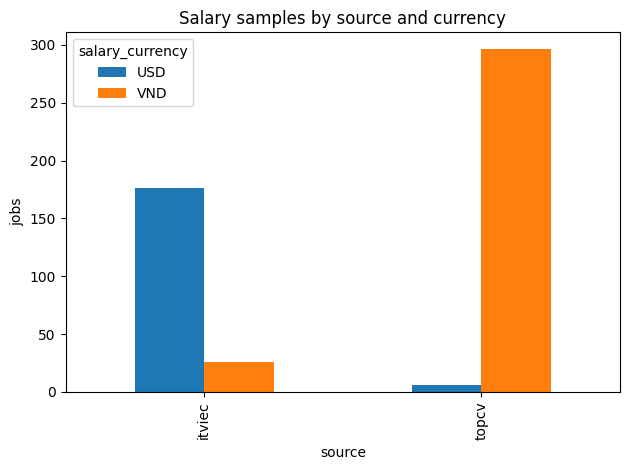

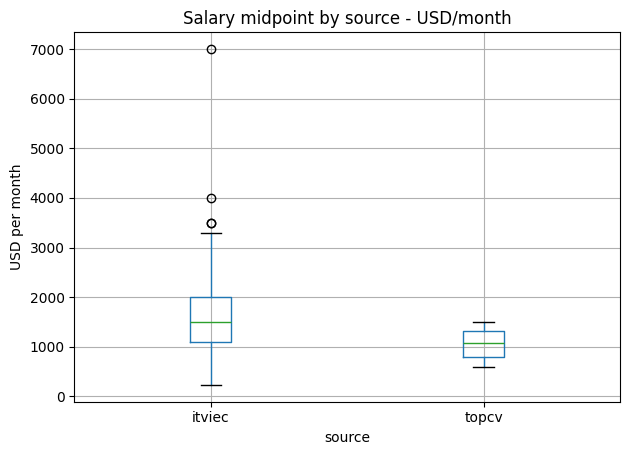

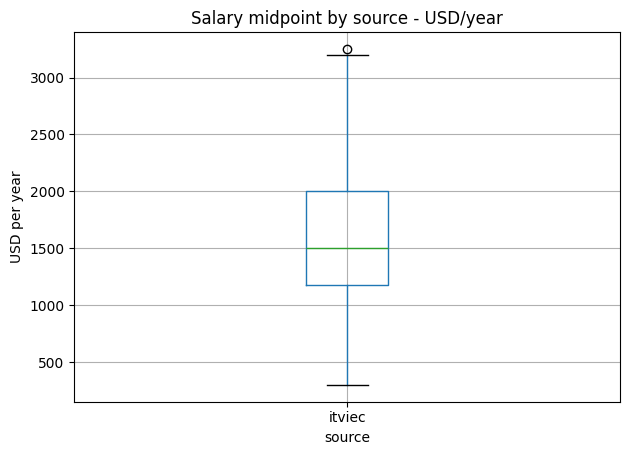

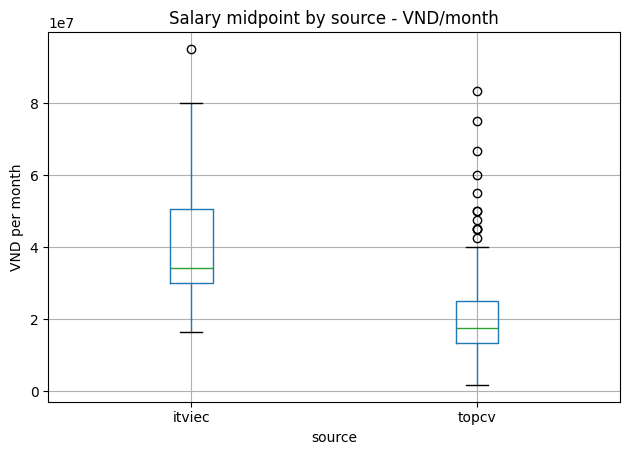

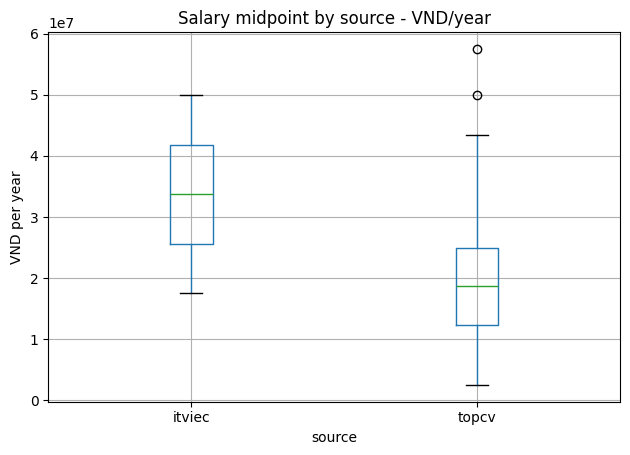

In [8]:
try:
    get_ipython()
    in_ipython = True
except NameError:
    in_ipython = False

if not in_ipython:
    plt = None
    print("Running outside IPython/Jupyter; skip charts during validation.")
else:
    try:
        import matplotlib.pyplot as plt
    except Exception as exc:
        plt = None
        print(f"matplotlib is unavailable; skip charts. Reason: {exc}")

if in_ipython and plt is not None:
    try:
        jobs_by_source_currency = salary_eda.groupby(["source", "salary_currency"]).size().unstack(fill_value=0)
        jobs_by_source_currency.plot(kind="bar", title="Salary samples by source and currency")
        plt.ylabel("jobs")
        plt.tight_layout()
        plt.show()

        for (currency, period), group in salary_eda.groupby(["salary_currency", "salary_period"]):
            group.boxplot(column="salary_midpoint", by="source")
            plt.title(f"Salary midpoint by source - {currency}/{period}")
            plt.suptitle("")
            plt.ylabel(f"{currency} per {period}")
            plt.tight_layout()
            plt.show()
    except Exception as exc:
        print(f"Could not render charts in this environment; skip charts. Reason: {exc}")

## 8. Seniority, work mode, employment type

Các nhóm này giúp hiểu salary samples đang nghiêng về level hoặc kiểu làm việc nào.

Pandas cần học: groupby nhiều cột và filter nhóm có sample size đủ lớn trước khi diễn giải.

In [9]:
def grouped_salary_summary(group_columns, min_jobs=3):
    summary = (
        salary_eda.groupby([*group_columns, "salary_currency", "salary_period"], dropna=False)
        .agg(
            jobs=("url", "count"),
            companies=("company", "nunique"),
            median_midpoint=("salary_midpoint", "median"),
            p25_midpoint=("salary_midpoint", lambda s: s.quantile(0.25)),
            p75_midpoint=("salary_midpoint", lambda s: s.quantile(0.75)),
        )
        .reset_index()
    )
    return summary.loc[summary["jobs"].ge(min_jobs)].sort_values(["salary_currency", "salary_period", "jobs"], ascending=[True, True, False])


display(grouped_salary_summary(["seniority"], min_jobs=3))
display(grouped_salary_summary(["work_mode"], min_jobs=3))
display(grouped_salary_summary(["employment_type"], min_jobs=3))

,seniority,salary_currency,salary_period,jobs,companies,median_midpoint,p25_midpoint,p75_midpoint
12,middle,USD,month,45,37,1350.0,1150.0,1500.0
16,senior,USD,month,40,33,1975.0,1400.0,2500.0
8,lead,USD,month,20,16,1975.0,1262.5,2762.5
4,junior,USD,month,15,14,1000.0,875.0,1425.0
20,<NA>,USD,month,15,13,1100.0,625.0,1824.5
0,intern,USD,month,4,3,350.0,282.5,525.0
17,senior,USD,year,18,12,2125.0,1587.5,2462.5
13,middle,USD,year,13,10,1350.0,1150.0,1500.0
9,lead,USD,year,5,5,1300.0,1250.0,1750.0
5,junior,USD,year,4,4,710.0,615.0,1000.0


,work_mode,salary_currency,salary_period,jobs,companies,median_midpoint,p25_midpoint,p75_midpoint
0,hybrid,USD,month,65,50,1400.0,1150.0,2000.0
8,remote,USD,month,51,39,1750.0,1159.5,2250.0
4,onsite,USD,month,23,20,1150.0,725.0,1525.0
1,hybrid,USD,year,24,20,1425.0,1187.5,1925.0
9,remote,USD,year,13,12,1500.0,1100.0,2000.0
5,onsite,USD,year,6,5,2125.0,1625.0,2437.5
6,onsite,VND,month,206,170,17500000.0,13500000.0,25000000.0
2,hybrid,VND,month,47,38,22500000.0,16000000.0,31250000.0
10,remote,VND,month,11,10,30000000.0,22500000.0,48500000.0
7,onsite,VND,year,46,40,17500000.0,11125000.0,24750000.0


,employment_type,salary_currency,salary_period,jobs,companies,median_midpoint,p25_midpoint,p75_midpoint
0,full_time,USD,month,139,100,1500.0,1075.0,2000.0
1,full_time,USD,year,43,32,1500.0,1175.0,2000.0
2,full_time,VND,month,264,211,20000000.0,14000000.0,28500000.0
3,full_time,VND,year,58,48,18750000.0,12500000.0,25000000.0


## 9. Experience buckets

Ta bucket hóa `experience_min` để nhìn phân bố dễ hơn. Đây là phân tích, không phải thay đổi parser.

Pandas cần học: `pd.cut()` để biến số liên tục thành nhóm.

In [10]:
salary_eda["experience_bucket"] = pd.cut(
    salary_eda["experience_min"],
    bins=[-1, 0, 1, 3, 5, 10, 100],
    labels=["0", "0-1", "1-3", "3-5", "5-10", "10+"],
)
salary_eda["experience_bucket"] = salary_eda["experience_bucket"].astype("string").fillna("unknown")

experience_summary = grouped_salary_summary(["experience_bucket"], min_jobs=3)
display(salary_eda["experience_bucket"].value_counts(dropna=False).rename_axis("experience_bucket").reset_index(name="jobs"))
display(experience_summary)

,experience_bucket,jobs
0,1-3,206
1,0-1,85
2,3-5,84
3,unknown,70
4,0,44
5,5-10,15


,experience_bucket,salary_currency,salary_period,jobs,companies,median_midpoint,p25_midpoint,p75_midpoint
8,1-3,USD,month,55,47,1400.0,1075.0,1650.0
12,3-5,USD,month,42,34,1925.0,1300.0,2500.0
19,unknown,USD,month,18,16,1575.0,650.0,2175.0
4,0-1,USD,month,9,7,1150.0,1050.0,1500.0
16,5-10,USD,month,8,8,2375.0,1987.5,3312.5
0,0,USD,month,7,6,400.0,325.0,700.0
9,1-3,USD,year,18,16,1425.0,1162.5,1500.0
13,3-5,USD,year,14,9,2250.0,1862.5,2462.5
5,0-1,USD,year,6,6,710.0,605.0,1175.0
10,1-3,VND,month,111,92,21500000.0,17500000.0,30000000.0


## 10. Skills salary samples

Cột `skills` đọc từ CSV có thể là chuỗi list. Ta parse thành list rồi `.explode()` để một dòng là một job-skill.

Pandas cần học: `.apply()`, `.explode()`, `.drop_duplicates()`, `.map()`.

In [11]:
def fold_text(value):
    if pd.isna(value):
        return ""
    text = str(value)
    text = "".join(
        character
        for character in unicodedata.normalize("NFD", text)
        if unicodedata.category(character) != "Mn"
    )
    return re.sub(r"\s+", " ", text).strip().casefold()


def to_listish(value):
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                return [str(item).strip() for item in parsed if str(item).strip()]
        except (ValueError, SyntaxError):
            pass
    return [part.strip() for part in text.replace(";", ",").split(",") if part.strip()]


skill_alias = {
    "js": "javascript",
    "reactjs": "react",
    "react.js": "react",
    "vuejs": "vue",
    "vue.js": "vue",
    "node": "node.js",
    "nodejs": "node.js",
    "golang": "go",
    "py": "python",
    "postgres": "postgresql",
    "k8s": "kubernetes",
    "ts": "typescript",
    "csharp": "c#",
    "dotnet": ".net",
    "ci cd": "ci/cd",
    "html5": "html",
    "css3": "css",
    "nextjs": "next.js",
    "nestjs": "nest.js",
}


def normalize_skill(value):
    folded = fold_text(value).replace("&", " and ")
    folded = re.sub(r"\s+", " ", folded).strip()
    return skill_alias.get(folded, folded)


salary_skills = (
    salary_eda[["url", "source", "title", "company", "salary_currency", "salary_period", "salary_midpoint", "skills"]]
    .assign(skill=salary_eda["skills"].apply(to_listish))
    .explode("skill", ignore_index=True)
)
salary_skills["skill"] = clean_text_series(salary_skills["skill"])
salary_skills["skill_norm"] = salary_skills["skill"].map(normalize_skill).astype("string")
salary_skills = (
    salary_skills.loc[salary_skills["skill_norm"].notna() & salary_skills["skill_norm"].ne("")]
    .drop_duplicates(["url", "skill_norm"])
    .reset_index(drop=True)
)

skill_salary_summary = (
    salary_skills.groupby(["skill_norm", "salary_currency", "salary_period"], dropna=False)
    .agg(
        salary_samples=("url", "nunique"),
        companies=("company", "nunique"),
        median_midpoint=("salary_midpoint", "median"),
        p25_midpoint=("salary_midpoint", lambda s: s.quantile(0.25)),
        p75_midpoint=("salary_midpoint", lambda s: s.quantile(0.75)),
    )
    .reset_index()
)

display(salary_skills.head(20))
display(skill_salary_summary.loc[skill_salary_summary["salary_samples"].ge(5)].sort_values(["salary_samples", "skill_norm"], ascending=[False, True]).head(40))

,url,source,title,company,salary_currency,salary_period,salary_midpoint,skills,skill,skill_norm
0,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",Java,java
1,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",HTML,html
2,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",Spring Boot,spring boot
3,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",Oracle,oracle
4,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",JavaScript,javascript
5,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",CSS,css
6,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",Angular,angular
7,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",.NET,.net
8,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",C#,c#
9,https://itviec.com/it-jobs/10-fullstack-deverloper-java-spring-boot-angular-thien-hoang-solutions-jsc-1448,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,USD,month,1400.0,"Java, HTML, Spring Boot, Oracle, JavaScript, CSS, Angular, .NET, C#, Docker, SQL, DevOps",Docker,docker


,skill_norm,salary_currency,salary_period,salary_samples,companies,median_midpoint,p25_midpoint,p75_midpoint
1013,sql,USD,month,50,43,1525.0,1212.5,1987.5
877,python,USD,month,43,35,1500.0,975.0,2125.0
1015,sql,VND,month,43,37,21500000.0,15250000.0,35000000.0
82,aws,USD,month,37,31,1650.0,1200.0,2000.0
240,docker,USD,month,30,25,1450.0,1162.5,1925.0
22,ai,USD,month,29,22,1600.0,1050.0,2250.0
432,javascript,USD,month,29,23,1400.0,1150.0,1900.0
232,devops,USD,month,27,22,1400.0,1100.0,1975.0
242,docker,VND,month,25,22,32500000.0,22500000.0,50000000.0
428,java,USD,month,25,19,1400.0,1200.0,2000.0


## 11. Top salary và bottom salary để review

Dù dataset đã lọc suspicious rows, extreme values vẫn nên được review trước khi kết luận.

Pandas cần học: `.sort_values()`, `.groupby()`, lấy top/bottom theo từng nhóm.

In [12]:
review_columns = [
    "source",
    "title",
    "company",
    "salary_raw",
    "salary_min",
    "salary_max",
    "salary_midpoint",
    "salary_currency",
    "salary_period",
    "experience_raw",
    "url",
]

top_salary_by_group = (
    salary_eda.sort_values("salary_midpoint", ascending=False)
    .groupby(["salary_currency", "salary_period"], dropna=False)
    .head(10)
    .sort_values(["salary_currency", "salary_period", "salary_midpoint"], ascending=[True, True, False])
)

bottom_salary_by_group = (
    salary_eda.sort_values("salary_midpoint", ascending=True)
    .groupby(["salary_currency", "salary_period"], dropna=False)
    .head(10)
    .sort_values(["salary_currency", "salary_period", "salary_midpoint"], ascending=[True, True, True])
)

display(top_salary_by_group[review_columns])
display(bottom_salary_by_group[review_columns])

,source,title,company,salary_raw,salary_min,salary_max,salary_midpoint,salary_currency,salary_period,experience_raw,url
111,itviec,"Principal Backend Engineer (AWS, TypeScript, DynamoDB)",ROWBOAT SOFTWARE,Upto $7000,NaN,7000.0,7000.0,USD,month,10+ years,https://itviec.com/it-jobs/principal-backend-engineer-aws-sql-rowboat-software-0838
142,itviec,"Senior Backend Dev ( AWS, JavaScript, NodeJS, GraphQL)",ROWBOAT SOFTWARE,3000 - 5000 USD,3000.0,5000.0,4000.0,USD,month,5+ years,https://itviec.com/it-jobs/senior-backend-developer-rowboat-software-1109
151,itviec,"Senior ""Embedded Android"" AOSP Developer",MIJO CONNECTED VIETNAM,2000 - 5000 USD,2000.0,5000.0,3500.0,USD,month,6+ years,https://itviec.com/it-jobs/senior-embedded-android-aosp-developer-mijo-connected-vietnam-4927
125,itviec,"Remote - Cyber Security Lead (OWASP, AWS, CISSP)",OrgScale Recruitment,2000 - 5000 USD,2000.0,5000.0,3500.0,USD,month,Minimum 5 years,https://itviec.com/it-jobs/remote-cyber-security-lead-owasp-aws-cissp-orgscale-recruitment-1505
132,itviec,"[Remote] Technical Leader (Database, Azure)- Upto 3300$",Catalytics Data International,Upto 3300$,NaN,3300.0,3300.0,USD,month,<NA>,https://itviec.com/it-jobs/remote-technical-leader-database-azure-upto-3300-catalytics-data-international-5749
4,itviec,AI Agent Engineer (Contract): Build the Agent Layer,Panto Martech LLC,2500 - 4000 USD,2500.0,4000.0,3250.0,USD,month,<NA>,https://itviec.com/it-jobs/ai-agent-engineer-contract-build-the-agent-layer-panto-martech-llc-4955
50,itviec,"Engineering Lead (Python, AI, Cloud Platform )",Skylink Labs,3000 - 3500 USD,3000.0,3500.0,3250.0,USD,month,<NA>,https://itviec.com/it-jobs/engineering-lead-python-ai-cloud-platform-skylink-labs-5029
148,itviec,"Senior Data Engineer (Python, SQL)",Công ty TNHH Stravo Vietnam,2000 - 4500 USD,2000.0,4500.0,3250.0,USD,month,7+ years,https://itviec.com/it-jobs/senior-data-engineer-python-sql-cong-ty-tnhh-stravo-vietnam-4421
94,itviec,Mid/Sr Ruby on Rails Developer (English),S4BT Solutions for Business Travel.,2500 - 3700 USD,2500.0,3700.0,3100.0,USD,month,Minimum of 5 years,https://itviec.com/it-jobs/mid-sr-ruby-on-rails-developer-english-s4bt-solutions-for-business-travel-0716
40,itviec,[Da Nang & Ho Chi Minh] Technical Architect,ONE Tech Stop Vietnam Company Ltd,2000 - 4000 USD,2000.0,4000.0,3000.0,USD,month,3-5 years,https://itviec.com/it-jobs/da-nang-ho-chi-minh-technical-architect-one-tech-stop-vietnam-company-ltd-4418


,source,title,company,salary_raw,salary_min,salary_max,salary_midpoint,salary_currency,salary_period,experience_raw,url
63,itviec,Generative Game Artist (Intern),Athena Studio,Approximately $230,230.0,NaN,230.0,USD,month,fresher,https://itviec.com/it-jobs/generative-game-artist-intern-athena-studio-0925
123,itviec,Prompt Engineer/Automation Engineer (Intern),Athena Studio,Approximately $300,300.0,NaN,300.0,USD,month,fresher,https://itviec.com/it-jobs/prompt-engineer-automation-engineer-intern-athena-studio-0137
36,itviec,Cộng tác viên An ninh thông tin (SOC) - Khối CNTT,Ngân hàng TMCP Tiên Phong | TPBank,200 - 500 USD,200.0,500.0,350.0,USD,month,<NA>,https://itviec.com/it-jobs/cong-tac-vien-an-ninh-thong-tin-soc-khoi-cntt-ngan-hang-tmcp-tien-phong-tpbank-4526
39,itviec,Cộng tác viên Vận hành Ứng dụng - Khối Công nghệ thông,Ngân hàng TMCP Tiên Phong | TPBank,200 - 500 USD,200.0,500.0,350.0,USD,month,<NA>,https://itviec.com/it-jobs/cong-tac-vien-van-hanh-ung-dung-khoi-cong-nghe-thong-ngan-hang-tmcp-tien-phong-tpbank-3018
38,itviec,Cộng tác viên Prompt Engineer – Khối CNTT,Ngân hàng TMCP Tiên Phong | TPBank,200 - 500 USD,200.0,500.0,350.0,USD,month,fresher,https://itviec.com/it-jobs/cong-tac-vien-prompt-engineer-khoi-cntt-ngan-hang-tmcp-tien-phong-tpbank-0040
191,itviec,Tập sự tiềm năng – AIOps/DevOps Engineer (AIO),Ngân hàng TMCP Tiên Phong | TPBank,200 - 500 USD,200.0,500.0,350.0,USD,month,2 năm,https://itviec.com/it-jobs/tap-su-tiem-nang-aiops-devops-engineer-aio-ngan-hang-tmcp-tien-phong-tpbank-0122
190,itviec,Tập sự tiềm năng – AI Engineer (AIE),Ngân hàng TMCP Tiên Phong | TPBank,200 - 500 USD,200.0,500.0,350.0,USD,month,2 năm,https://itviec.com/it-jobs/tap-su-tiem-nang-ai-engineer-aie-ngan-hang-tmcp-tien-phong-tpbank-0755
37,itviec,Cộng tác viên Dự án - Khối Công nghệ thông tin,Ngân hàng TMCP Tiên Phong | TPBank,200 - 500 USD,200.0,500.0,350.0,USD,month,<NA>,https://itviec.com/it-jobs/cong-tac-vien-du-an-khoi-cong-nghe-thong-tin-ngan-hang-tmcp-tien-phong-tpbank-3541
199,itviec,Thực tập sinh Khoa học Dữ liệu,VCS Viet Nam,300 - 500 USD,300.0,500.0,400.0,USD,month,fresher,https://itviec.com/it-jobs/thuc-tap-sinh-khoa-hoc-du-lieu-vcs-viet-nam-2131
221,topcv,Business Analyst - IT (Chuyên Viên Phân Tích Nghiệp Vụ - CNTT),NGÂN HÀNG TNHH INDOVINA,550 - 650 USD,550.0,650.0,600.0,USD,month,<NA>,https://www.topcv.vn/viec-lam/business-analyst-it-chuyen-vien-phan-tich-nghiep-vu-cntt/2212392.html


## 12. Câu hỏi phân tích tiếp theo

Các câu hỏi nên trả lời sau khi đã hiểu file này:

- Median salary theo source có khác nhau không, hay do sample mix khác nhau?
- USD/month và VND/month có nên quy đổi chung không? Nếu có, cần chọn tỷ giá và ghi rõ ngày.
- Những skill có salary cao có đủ sample size chưa?
- Salary theo seniority có hợp lý không, hay parser đang suy luận seniority quá rộng?
- Các row top/bottom salary có phải job thật hay parser cần cải thiện?